In [107]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [108]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process.binning import add_cns_loc, group_bins, sum_cns
from cns.display.plot import plot_lines, fig_lines, fig_dots
from cns.data_utils import  main_load_data, get_cns_for_type, load_samples_out, load_merged_samples, load_all_samples

In [109]:
tcga_samples = load_samples_out("TCGA_hg19_samples.tsv")
len(tcga_samples[tcga_samples["type"] == 'LUAD']) 

415

In [110]:
samples_df, cns_df = main_load_data("1MB")
datasets = samples_df["source"].unique()

In [111]:
luad_dict = { k : get_cns_for_type(cns_df, samples_df.query(f"source == '{k}'"), "LUAD") for k in datasets }
lusc_dict = { k : get_cns_for_type(cns_df, samples_df.query(f"source == '{k}'"), "LUSC") for k in datasets }
means_single = [group_bins(dataset) for dataset in [v for k, v in luad_dict.items()] + [v for k, v in lusc_dict.items()]]
luad_all = pd.concat([v for k, v in luad_dict.items()])
lusc_all = pd.concat([v for k, v in lusc_dict.items()])
means_all = [group_bins(dataset) for dataset in [luad_all, lusc_all]]

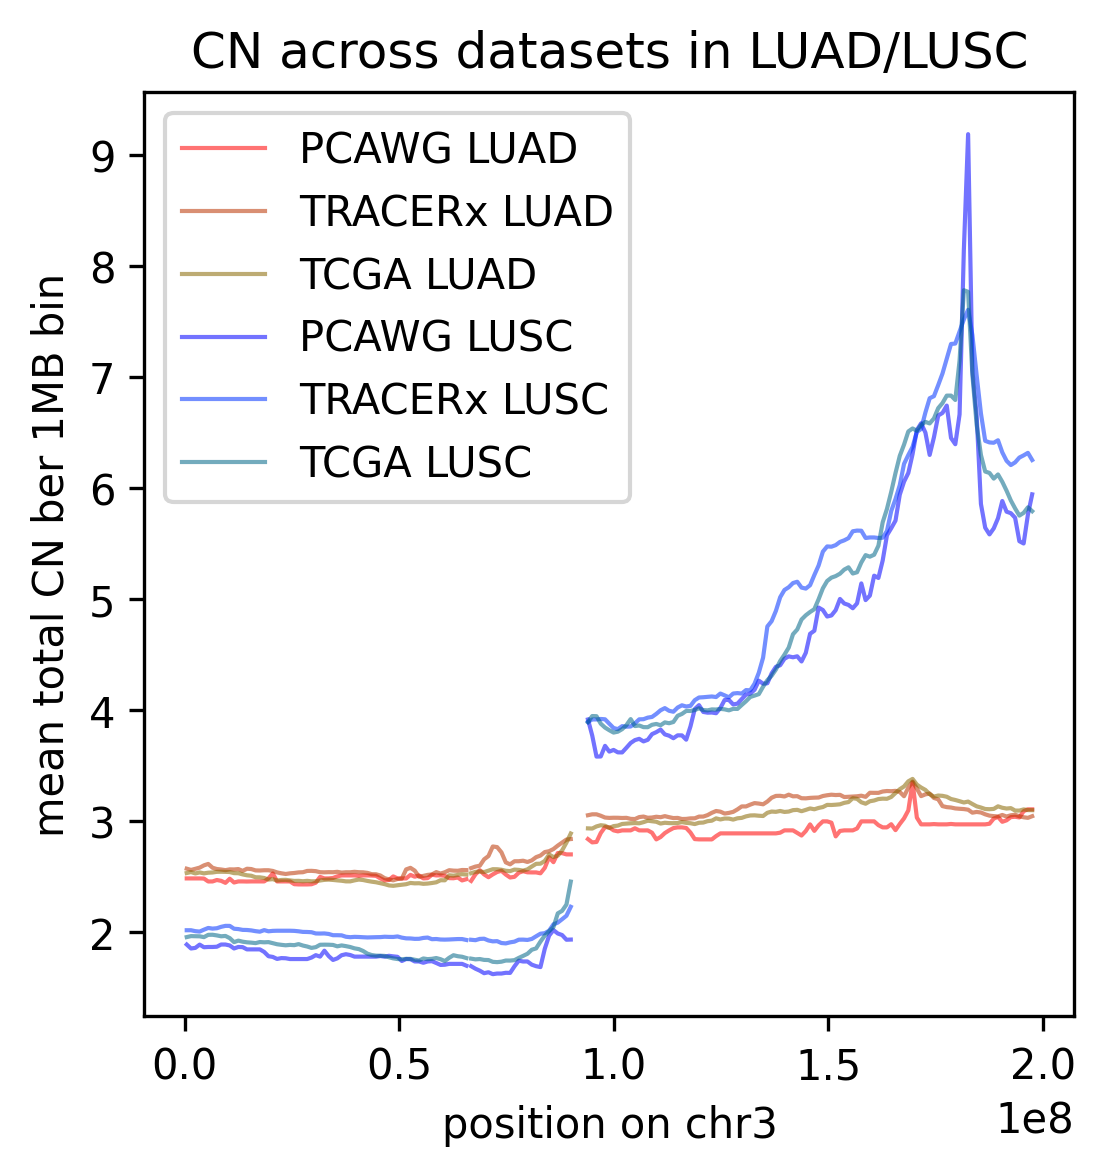

In [112]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
fig, ax = fig_lines(means_single, labels, column="total_cn", color=["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"], dpi=300, chrom="chr3")
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')
plt.savefig("../../out/fig_LUAD_LUSC_single.pdf", bbox_inches='tight')

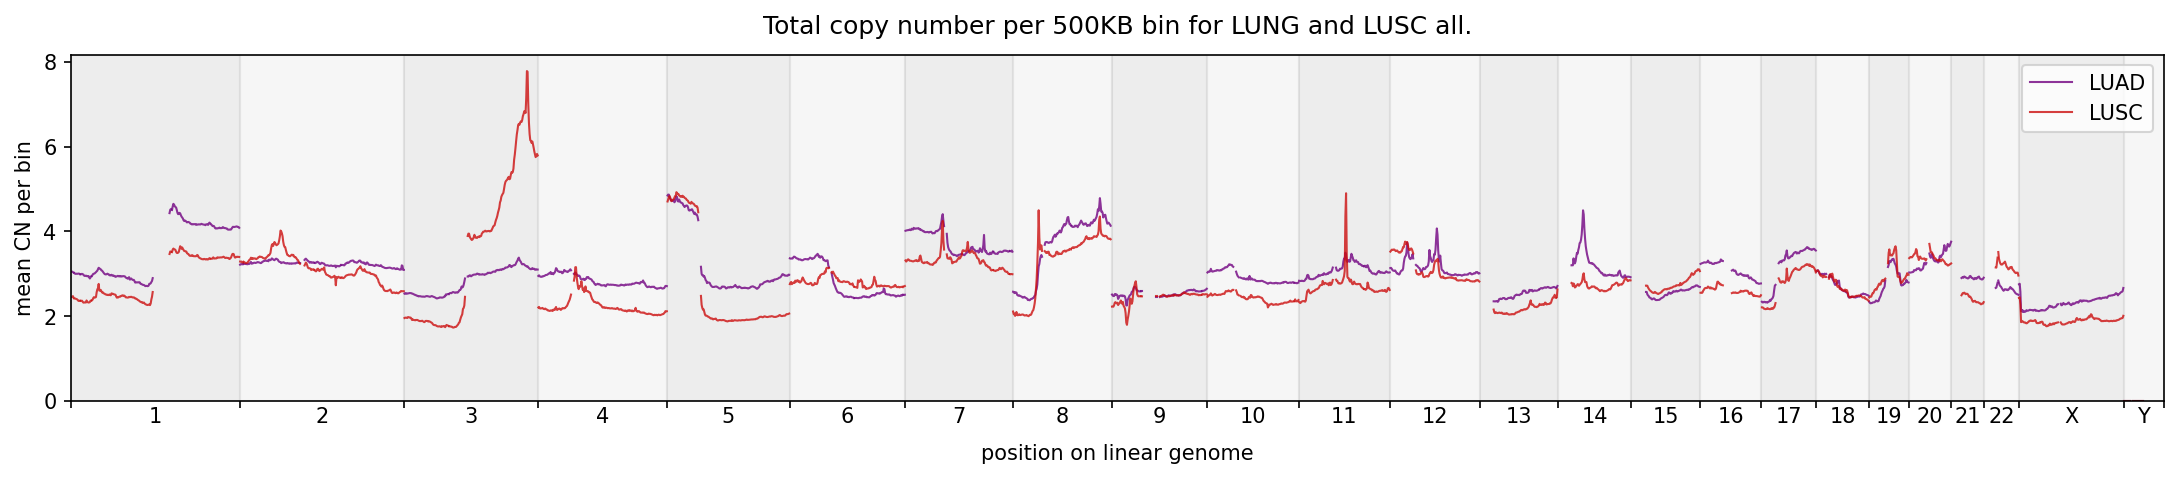

In [77]:
fig, ax = fig_lines(means_all, ["LUAD", "LUSC"], column="total_cn", dpi=150)
ax.set_title("Total copy number per 500KB bin for LUNG and LUSC all.", pad=10)
plt.savefig("../../out/fig_LUAD_LUSC_all.pdf", bbox_inches='tight')

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

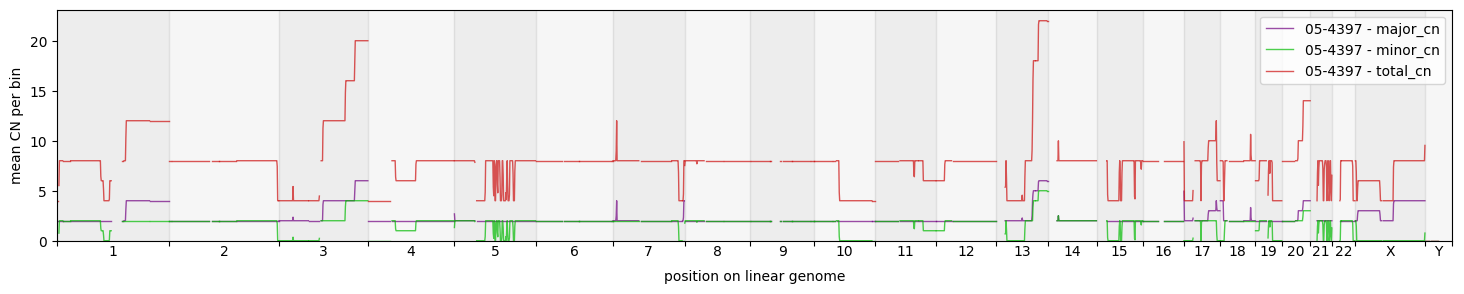

In [78]:
tcga_sel_ids = list(samples_df.query("source == 'TCGA_hg19' and type == 'LUAD'").index[9:10])

groups = []
for id in tcga_sel_ids:
	select_cns = cns_df.set_index("sample_id").loc[id].reset_index()
	groups.append(sum_cns(add_cns_loc(select_cns)))

shorten = [name[-7:] for name in tcga_sel_ids]
fig_lines(groups, shorten)

(0.0, 10.0)

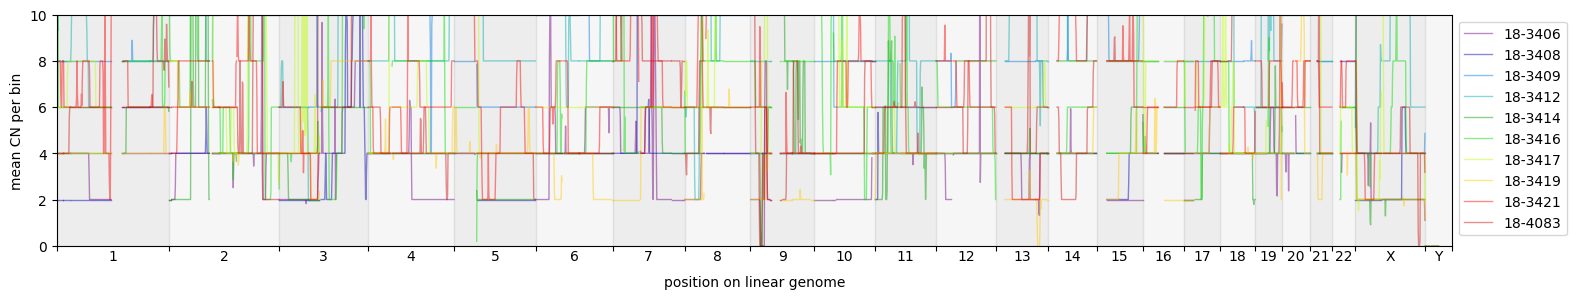

In [79]:
tcga_sel_ids = list(samples_df.query("source == 'TCGA_hg19' and type == 'LUSC'").index[:10])

groups = []
for id in tcga_sel_ids:
	select_cns = cns_df.set_index("sample_id").loc[id].reset_index()
	groups.append(sum_cns(add_cns_loc(select_cns)))

shorten = [name[-7:] for name in tcga_sel_ids]
fig, ax = fig_lines(groups, shorten, column="total_cn")
ax.set_ylim(0,10)

In [80]:
_, cosmic_df = main_load_data("COSMIC")

In [81]:
cosmic_group = group_bins(cosmic_df)
cosmic_group.head()

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn
0,2200845,chr1,2160133,2241558,2200845,81425,1.623201,0.923749,2.546950
1,2491949,chr1,2487077,2496821,2491949,9744,1.612577,0.919551,2.532128
2,3170458,chr1,2985731,3355185,3170458,369454,1.593643,0.911498,2.505141
3,6255388,chr1,6241328,6269449,6255388,28121,1.586018,0.900103,2.486121
4,7337574,chr1,6845383,7829766,7337574,984383,1.579078,0.895648,2.474726


In [82]:
from cns.data_utils import load_COSMIC

cosmic_genes = load_COSMIC()
cosmic_genes.head()

,gene,chrom,start,end
0,SKI,chr1,2160133,2241558
1,TNFRSF14,chr1,2487077,2496821
2,PRDM16,chr1,2985731,3355185
3,RPL22,chr1,6241328,6269449
4,CAMTA1,chr1,6845383,7829766


In [83]:
cosmic_lusc_group = group_bins(get_cns_for_type(cosmic_df, samples_df, "LUSC"))
cosmic_lusc_group = cosmic_lusc_group.merge(cosmic_genes, on=["chrom", "start", "end"])
cosmic_luad_group = group_bins(get_cns_for_type(cosmic_df, samples_df, "LUAD"))
cosmic_luad_group = cosmic_luad_group.merge(cosmic_genes, on=["chrom", "start", "end"])

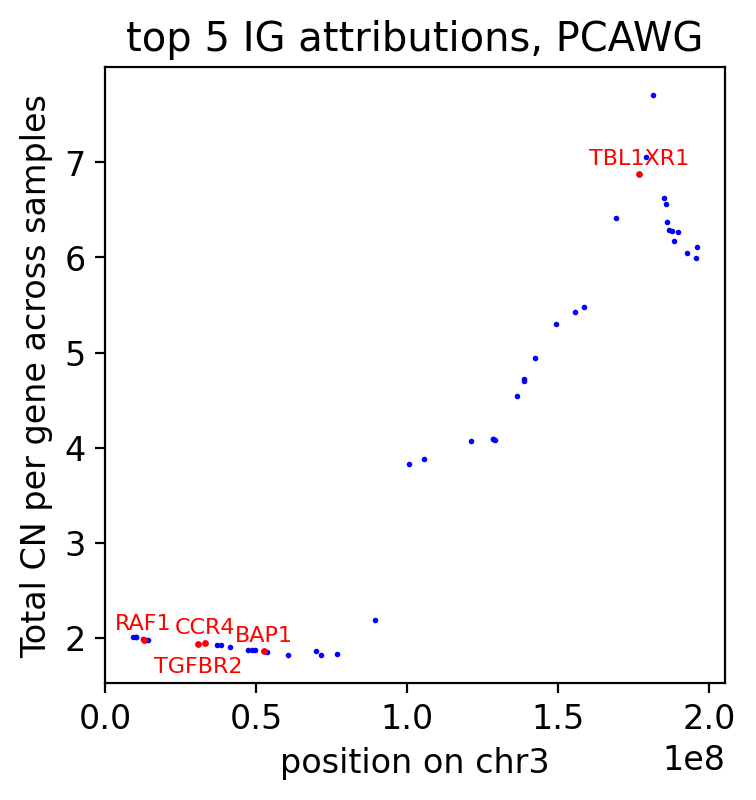

In [118]:
from cns.display.plot import fig_dots


# increase font size in figure
plt.rcParams.update({'font.size': 12})

fig, ax = fig_dots(cosmic_lusc_group, chrom="chr3", column="total_cn", dpi=200)

genes = ['TGFBR2', 'CCR4', 'BAP1', 'RAF1', 'TBL1XR1']

for i, row in cosmic_lusc_group.iterrows():
    if row['gene'] in genes:
        plt.scatter(row['mid'], row['total_cn'], color='red', s=2)
        offset = -.3 if row['gene'] in ['TGFBR2'] else 0.1
        text = f"{row['gene']}"
        plt.text(row['mid'], row['total_cn'] + offset, text, color="red", size=8, ha='center')

ax.set_ylabel("Total CN per gene across samples")
plt.title("top 5 IG attributions, PCAWG")

plt.savefig("../../out/fig_COSMIC_genes_IG_att.pdf", bbox_inches='tight')
plt.show()

In [85]:
chrom_3 = cosmic_lusc_group.query("chrom == 'chr3'")
chrom_3.loc[140:158]

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn,gene
140,613657559,chr3,121150277,121264853,121207565,114576,2.684460,1.380783,4.065243,POLQ
141,620655142,chr3,128198269,128212028,128205148,13759,2.705813,1.381969,4.087782,GATA2
142,620819361,chr3,128338816,128399918,128369367,61102,2.705813,1.379597,4.085409,RPN1
143,621345539,chr3,128888326,128902765,128895545,14439,2.698695,1.380783,4.079478,CNBP
144,628713142,chr3,136055076,136471220,136263148,416144,3.088968,1.448399,4.537367,STAG1
145,630913313,chr3,138372859,138553780,138463319,180921,3.223013,1.480427,4.703440,PIK3CB
146,631114517,chr3,138663065,138665982,138664523,2917,3.243179,1.482800,4.725979,FOXL2
147,634682866,chr3,142168076,142297668,142232872,129592,3.416370,1.521945,4.938316,ATR
148,641794755,chr3,149235021,149454501,149344761,219480,3.720047,1.576512,5.296560,WWTR1
149,648075063,chr3,155588324,155661815,155625069,73491,3.820878,1.604982,5.425860,GMPS


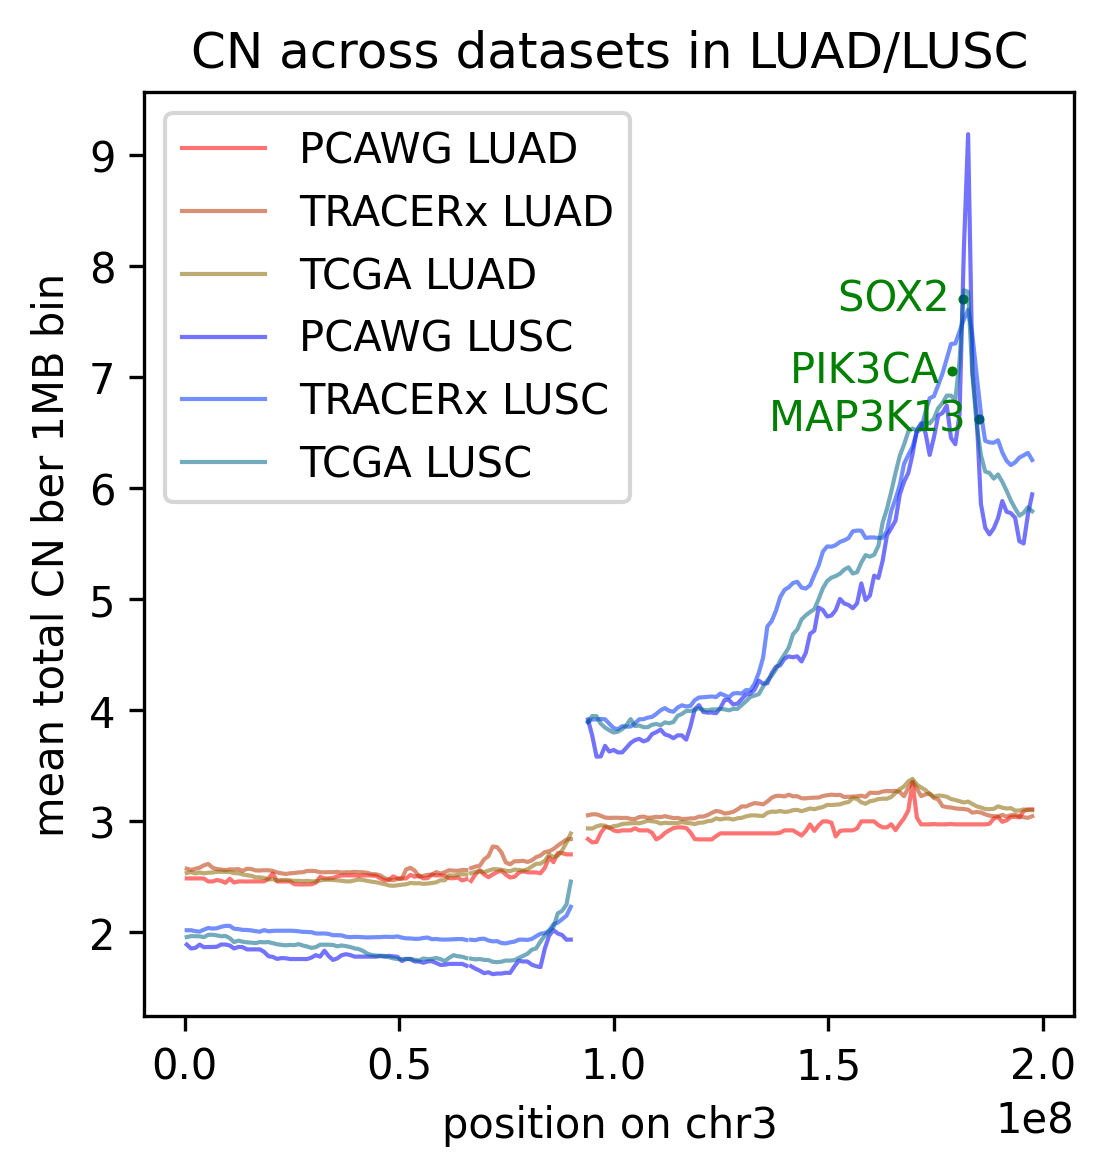

In [116]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
fig, ax = fig_lines(means_single, labels, column="total_cn", color=["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"], dpi=300, chrom="chr3")
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')

for i, row in cosmic_lusc_group.iterrows():
    if row['gene'] in ["PIK3CA", "SOX2", "MAP3K13"]:
        plt.scatter(row['mid'], row['total_cn'], color='green', s=2)
        offset = 0
        text = f"{row['gene']} "
        plt.text(row['mid'], row['total_cn'] + offset, text, color="green", size=10, ha='right', va='center')

plt.savefig("../../out/fig_LUAD_LUSC_single.pdf", bbox_inches='tight')
